In [8]:
print('hello')

hello


In [9]:
import os
import cv2
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import keras
import tensorflow

from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import VGG19
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input,Lambda,Dense,Flatten,Dropout,BatchNormalization,Activation

from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,recall_score,precision_score,f1_score

In [10]:
pip install split-folders[full]

     ---------------------------------------- 0.0/57.6 kB ? eta -:--:--
     ------- -------------------------------- 10.2/57.6 kB ? eta -:--:--
     ---------------------------------------- 57.6/57.6 kB 1.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/78.3 kB ? eta -:--:--
   ---------------------------------------- 78.3/78.3 kB 2.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [14]:
import splitfolders
input_folder = "C:\Projects\Python\ELC\D3SSubjectData\Sub1"
splitfolders.ratio(input_folder,output = r"C:\Projects\Python\ELC\D3SSubjectData\Sub1_seg",
                   seed = 1337,ratio = (0.7,0.2,0.1),
                   group_prefix = None
                   )

Copying files: 1319 files [00:00, 1500.22 files/s]


In [21]:
 train_path = r'C:\Projects\Python\ELC\D3SSubjectData\Sub1_seg\train'
 test_path = r'C:\Projects\Python\ELC\D3SSubjectData\Sub1_seg\test'
 val_path = r'C:\Projects\Python\ELC\D3SSubjectData\Sub1_seg\val'

Eyeclose


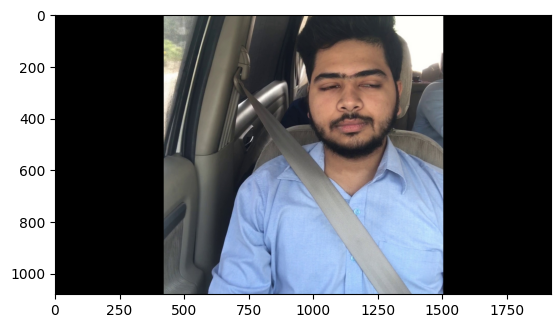

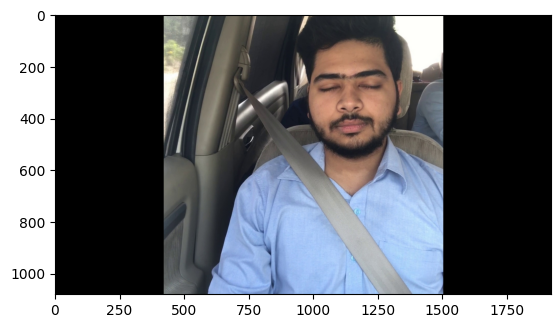

Happy


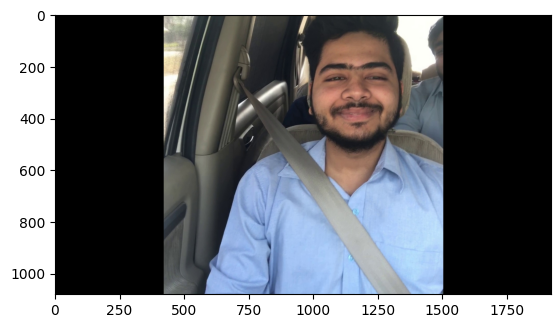

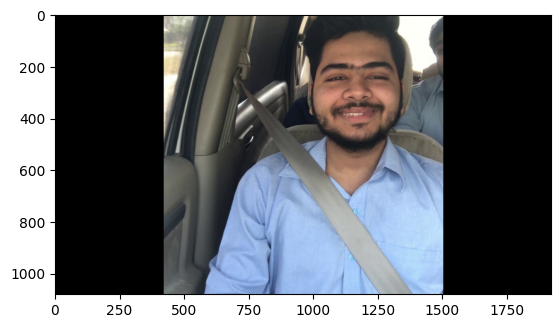

Neutral


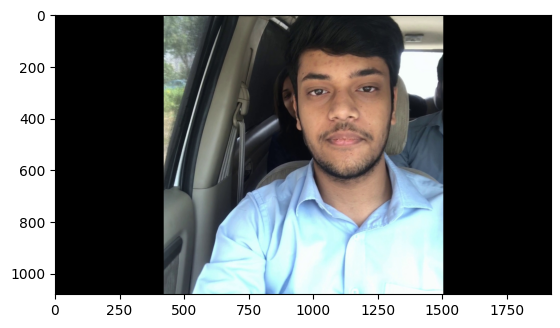

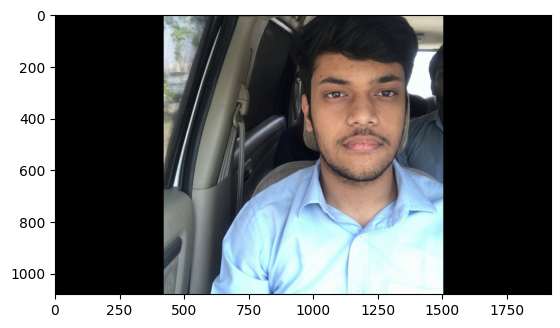

Yawn


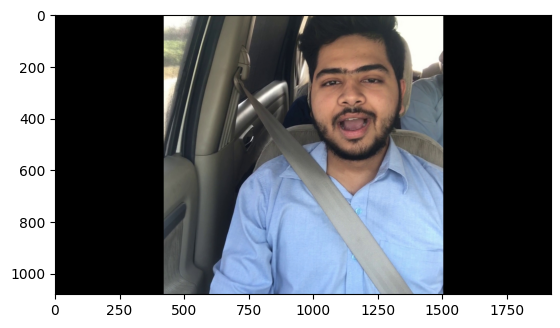

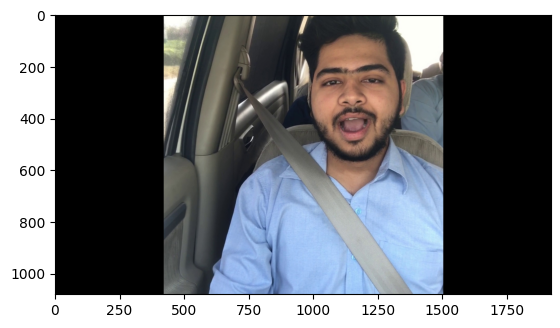

In [22]:
  for folder in os.listdir(train_path):
      sub_path = os.path.join(train_path, folder)
      print(folder)

      # Ensure that you list the images inside each folder
      images = os.listdir(sub_path)

      for i in range(min(2, len(images))):  # Ensure you don't go out of bounds
          temp_path = os.path.join(sub_path, images[i])
          img = mpimg.imread(temp_path)
          plt.imshow(img)
          plt.show()

In [23]:
def imagearray(path,size):
  data = []
  for folder in os.listdir(path):
    sub_path = os.path.join(path, folder)

    for img in os.listdir(sub_path):
      image_path = os.path.join(sub_path, img)
      img = cv2.imread(image_path)
      img = cv2.resize(img,size)
      data.append(img)
  return data

In [24]:
size = (224,224)
train_data = imagearray(train_path,size)
test_data = imagearray(test_path,size)
val_data = imagearray(val_path,size)

In [25]:
train_data = np.array(train_data)
test_data = np.array(test_data)
val_data = np.array(val_data)

In [26]:
x_train = train_data/255
x_test = test_data/255
x_val = val_data/255

In [27]:
def data_class(data_path,size,class_mode):
  datagen=ImageDataGenerator(rescale=1./255)
  return datagen.flow_from_directory(data_path,target_size=size,batch_size=32,class_mode=class_mode)

In [28]:
train_class = data_class(train_path,size,'sparse')
test_class = data_class(test_path,size,'sparse')
val_class = data_class(val_path,size,'sparse')

Found 921 images belonging to 4 classes.
Found 136 images belonging to 4 classes.
Found 262 images belonging to 4 classes.


In [29]:
y_train=train_class.classes
y_test=test_class.classes
y_val=val_class.classes

In [30]:
train_class.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [31]:
train_class.class_indices

{'Eyeclose': 0, 'Happy': 1, 'Neutral': 2, 'Yawn': 3}

In [32]:
print("y_train_shape",y_train.shape,
"y_test_shape",y_test.shape,
"y_val_shape",y_val.shape)

y_train_shape (921,) y_test_shape (136,) y_val_shape (262,)


In [33]:
vgg=VGG19(weights='imagenet',include_top=False,input_shape=(224,224,3))

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


In [34]:
for layers in vgg.layers:
  layers.trainable=False

In [35]:
x=Flatten()(vgg.output)
prediction=Dense(5,activation='softmax')(x)

In [36]:
model=Model(inputs=vgg.input,outputs=prediction)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │       125,445 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,149,829 (76.87 MB)

 Trainable params: 125,445 (490.02 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [37]:
 plot_model(model=model,show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [38]:
early_stop=EarlyStopping(monitor='val_loss',patience=3,verbose=1,mode='min')

In [39]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [40]:
model.fit(x_train,y_train,
          epochs=5,
          validation_data=(x_val,y_val),
          callbacks=[early_stop],
          batch_size=30,
          shuffle=True)

Epoch 1/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.4389 - loss: 1.9008 - val_accuracy: 0.8053 - val_loss: 0.5474
Epoch 2/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.8159 - loss: 0.4966 - val_accuracy: 0.9389 - val_loss: 0.2824
Epoch 3/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.9520 - loss: 0.2525 - val_accuracy: 0.9656 - val_loss: 0.1738
Epoch 4/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.9565 - loss: 0.1800 - val_accuracy: 0.9809 - val_loss: 0.1321
Epoch 5/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 77s 3s/step - accuracy: 0.9904 - loss: 0.1106 - val_accuracy: 0.9542 - val_loss: 0.1390


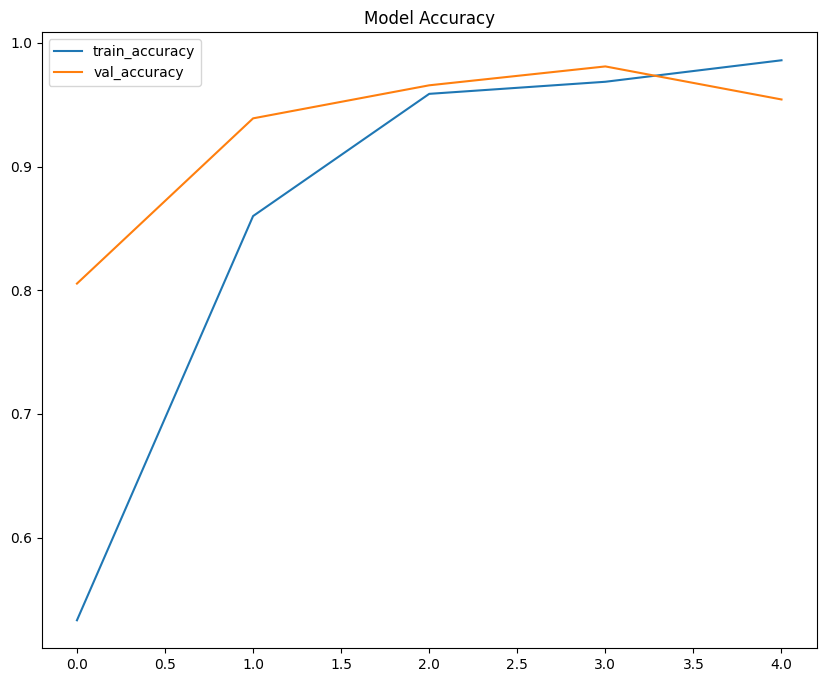

In [41]:
plt.figure(figsize=(10,8))
plt.plot(model.history.history['accuracy'],label='train_accuracy')
plt.plot(model.history.history['val_accuracy'],label='val_accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

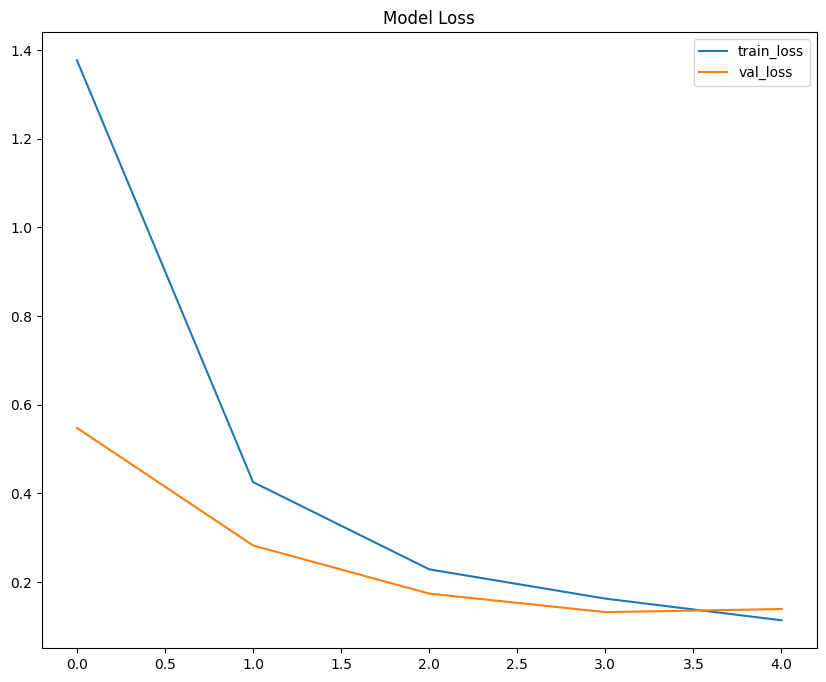

In [42]:
plt.figure(figsize=(10,8))
plt.plot(model.history.history['loss'],label='train_loss')
plt.plot(model.history.history['val_loss'],label='val_loss')
plt.legend()
plt.title('Model Loss')
plt.show()

In [43]:
model.evaluate(x_test,y_test,batch_size=32)

5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.9853 - loss: 0.0987


[0.0964493602514267, 0.9779411554336548]

In [44]:
y_pred=model.predict(x_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step


In [45]:
y_pred=np.argmax(y_pred,axis=1)

In [46]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        63
           1       1.00      0.83      0.91        12
           2       0.98      1.00      0.99        43
           3       1.00      0.94      0.97        18

    accuracy                           0.98       136
   macro avg       0.99      0.94      0.96       136
weighted avg       0.98      0.98      0.98       136



Text(0.5, 1.0, 'Confusion Matrix')

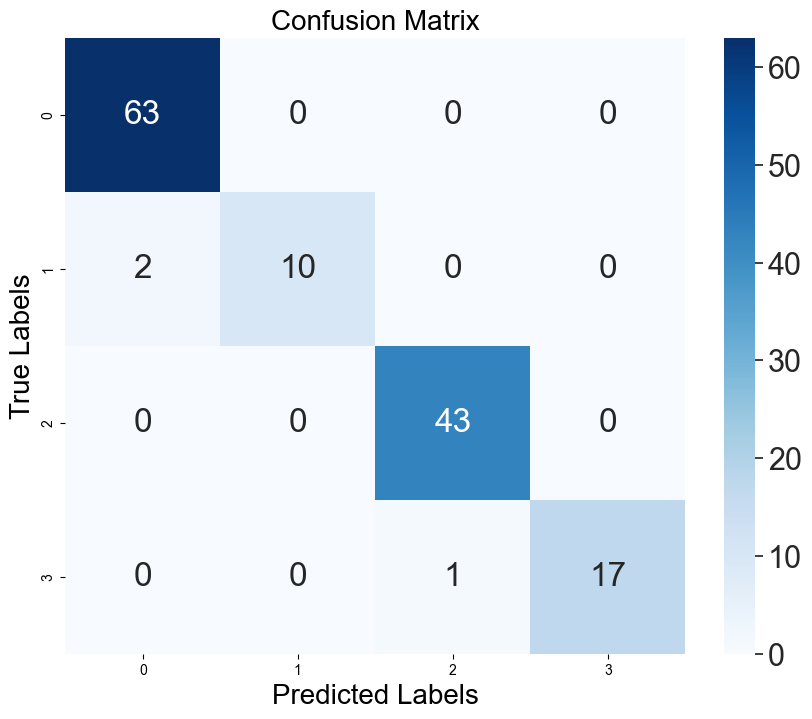

In [47]:
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(10,8))
ax=plt.subplot()
sns.set(font_scale=2.0)
sns.heatmap(cm,annot=True,fmt='g',cmap='Blues',ax=ax)
#Labels,title and Ticks
ax.set_xlabel('Predicted Labels',fontsize=20);
ax.set_ylabel('True Labels',fontsize=20);
ax.set_title('Confusion Matrix',fontsize=20)

In [48]:
f1_score(y_test,y_pred,average='macro')

0.9633500569114793

In [49]:
recall_score(y_test,y_pred,average='weighted')

0.9779411764705882

In [50]:
precision_score(y_test,y_pred,average='micro')

0.9779411764705882

In [53]:
model.save("C:\Projects\Python\ELC.keras")